In [61]:
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
from sksurv.nonparametric import kaplan_meier_estimator

In [46]:
df = pl.read_parquet("final_patient_data.parquet")


In [47]:
df.head(1)

patient_id,hosp_id,centre,hosp_admission_datetime,hosp_discharge_datetime,inclusion_flag,icu_stay_flag,Cardiopathie ischémique,Fibrillation atriale,Insuffisance cardiaque chronique,Pacemaker,Pontage aorto-coronarien,Insuffisance rénale chronique,Antécédent d'AVC,Cirrhose,Cancer actif,Immunodépression,Dyslipidémie,Diabète,beta_blocker,ACEI,ARB,anti_aldosterone,furosemide,gender,birth_date,death_date,age_at_admission,comorbidity_score,hfrs_score,OMT_component_score,death_flag
str,i64,str,datetime[μs],datetime[μs],i64,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,str,date,date,i32,f64,f64,i8,i32
"""P001""",1002,"""angers""",2018-07-04 11:15:00,2018-07-12 10:00:00,1,0,1,1,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,"""F""",1933-04-12,2018-09-21,85,0.0,0.0,2,1


In [48]:
cv_cols = [
    "Cardiopathie ischémique",
    "Fibrillation atriale",
    "Insuffisance cardiaque chronique",
    "Pacemaker",
    "Pontage aorto-coronarien",
    "Antécédent d'AVC",
]
df = df.with_columns(
    (
        pl.sum_horizontal([pl.col(c) for c in cv_cols]) >= 1
    )
    .cast(pl.Int8)
    .alias("cv_history")
)

In [49]:
df.head(1)

patient_id,hosp_id,centre,hosp_admission_datetime,hosp_discharge_datetime,inclusion_flag,icu_stay_flag,Cardiopathie ischémique,Fibrillation atriale,Insuffisance cardiaque chronique,Pacemaker,Pontage aorto-coronarien,Insuffisance rénale chronique,Antécédent d'AVC,Cirrhose,Cancer actif,Immunodépression,Dyslipidémie,Diabète,beta_blocker,ACEI,ARB,anti_aldosterone,furosemide,gender,birth_date,death_date,age_at_admission,comorbidity_score,hfrs_score,OMT_component_score,death_flag,cv_history
str,i64,str,datetime[μs],datetime[μs],i64,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,i8,str,date,date,i32,f64,f64,i8,i32,i8
"""P001""",1002,"""angers""",2018-07-04 11:15:00,2018-07-12 10:00:00,1,0,1,1,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,"""F""",1933-04-12,2018-09-21,85,0.0,0.0,2,1,1


In [50]:
df = df.select([
    "patient_id", "hosp_admission_datetime", "death_date", "cv_history"
])

In [51]:
df.head(1)

patient_id,hosp_admission_datetime,death_date,cv_history
str,datetime[μs],date,i8
"""P001""",2018-07-04 11:15:00,2018-09-21,1


In [52]:
df = df.to_pandas()

In [53]:
# Create a one-year follow-up limit for each patient (admission date + 365 days)
df["one_year_limit"] = df["hosp_admission_datetime"]+pd.Timedelta(days=365)

In [54]:
df.head(1)

,patient_id,hosp_admission_datetime,death_date,cv_history,one_year_limit
0,P001,2018-07-04 11:15:00,2018-09-21,1,2019-07-04 11:15:00


In [56]:
# Define the actual end of follow-up for each patient:
# use the death date if available; otherwise, use the one-year limit
df["end_followup"] = df["death_date"].fillna(df["one_year_limit"])

# If the death date is beyond the one-year limit, censor follow-up at the one-year limit
df.loc[df["end_followup"] > df["one_year_limit"], "end_followup"] = (
    df["one_year_limit"]
)

In [57]:
# 3. Calculate the elapsed follow-up time in days
# This is the time variable used in the Kaplan-Meier estimator
df["time"] = (
    df["end_followup"]-df["hosp_admission_datetime"]
).dt.days

In [63]:
# 4. Determine whether death occurred within this follow-up period
# This is the status/event variable
df["status"] = (df["death_date"].notna()) & (
    df["death_date"] < df["one_year_limit"]
)

In [64]:
df.head()

,patient_id,hosp_admission_datetime,death_date,cv_history,one_year_limit,end_followup,time,status
0,P001,2018-07-04 11:15:00,2018-09-21,1,2019-07-04 11:15:00,2018-09-21 00:00:00,78,True
1,P002,2019-01-18 13:20:00,NaT,0,2020-01-18 13:20:00,2020-01-18 13:20:00,365,False
2,P003,2019-04-09 09:15:00,2020-12-04,1,2020-04-08 09:15:00,2020-04-08 09:15:00,365,False
3,P004,2018-03-03 07:50:00,NaT,1,2019-03-03 07:50:00,2019-03-03 07:50:00,365,False
4,P005,2019-02-01 14:10:00,2019-03-17,0,2020-02-01 14:10:00,2019-03-17 00:00:00,43,True


In [65]:
group_cv_yes = df[df["cv_history"] == 1]
group_cv_no = df[df["cv_history"] == 0]

time_yes, surv_yes = kaplan_meier_estimator(
    group_cv_yes["status"], group_cv_yes["time"]
)

time_no, surv_no = kaplan_meier_estimator(
    group_cv_no["status"], group_cv_no["time"]
)

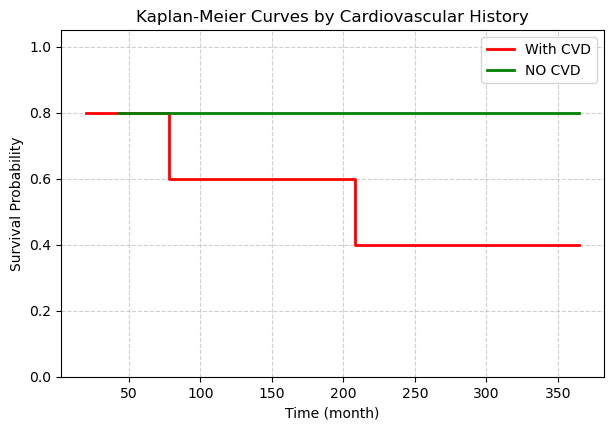

In [66]:
plt.figure(figsize=(7, 4.5))
plt.step(
    time_yes,
    surv_yes,
    where = "post",
    color = "red",
    label = "With CVD",
    linewidth = 2
)

plt.step(
    time_no,
    surv_no,
    where = "post",
    color = "green",
    label = "NO CVD",
    linewidth = 2
)

plt.title("Kaplan-Meier Curves by Cardiovascular History")
plt.xlabel("Time (month)")
plt.ylabel("Survival Probability")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True, linestyle = "--", alpha = 0.6)
plt.show()